In [2]:
import os
import re
import json
import random
import pickle as pk
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [3]:
random.seed(42)

In [4]:
load_dotenv()
QUESTIONS_MULTIMODALQA_TRAINING = os.getenv("QUESTIONS_MULTIMODALQA_TRAINING")
selected_questions = pk.load(open("/Users/emanuelemezzi/PycharmProjects/LEGuidance/scripts/selected_questions.pk", "rb"))

In [77]:
len(selected_questions)

6363

In [80]:
def build_dataset(model, selected_questions):
    questions = {}
    for i, question in enumerate(selected_questions):
        criteria_json = json.load(open(os.path.join(f"/Users/emanuelemezzi/PycharmProjects/LEGuidance/results/criteria_extraction/{model}/iteration_0", question), "rb"))

        question_json = json.load(open(os.path.join(QUESTIONS_MULTIMODALQA_TRAINING, question), "rb"))

        questions[question] = {}
        data = {}

        data["original_question"] = criteria_json["original_question"]
        data["question_length"] = len(criteria_json["original_question"])
        data["question_topic"] = criteria_json["topic"]["question_topic"]
        data["question_answer_class_specific"] = criteria_json["expected_answer_type"]["expected_answer_type_specific"]
        data["question_answer_class_general"] = criteria_json["expected_answer_type"]["expected_answer_type_general"]
        data["modality"] = question_json["metadata"]["modalities"]

        questions[question] = data

    dataset = pd.DataFrame(questions).T

    with open("tree_dataset.pkl", "wb") as file:
        pk.dump(dataset, file)

In [81]:
build_dataset("gpt-5.2", selected_questions)

In [5]:
tree_dataset = pk.load(open("tree_dataset.pkl", "rb"))

In [6]:
tree_dataset

,original_question,question_length,question_topic,question_answer_class_specific,question_answer_class_general,modality
question_3158.json,Did Cristiano dos Santos Rodrigues play in mor...,76,Sports,season (which had more games played),comparison result,"[table, table]"
question_13163.json,Which of the home media of ICarly : the Comple...,99,Television,home media release (which one has higher disc ...,media release,"[table, table]"
question_10777.json,"Was It's Like, You Know... or Friends, the one...",106,Television,television series title (one of two options),work,"[table, table]"
question_6283.json,The Usher song Yeah! charted lower in which Ch...,119,Music,chart (music chart name/market),chart,"[table, table]"
question_17285.json,In the chart performance from 1983 for the son...,152,Music,chart name (which had the lower peak position),string,"[table, table]"
...,...,...,...,...,...,...
question_23543.json,"Which Location(s), in Teams and locations of 1...",112,Sports,location(s) (place names listed in 'Teams and ...,location,[image]
question_15516.json,What color jacket is Hammer & Tongs wearing?,44,Other,color (jacket color),attribute,[image]
question_189.json,What color teeth does Goldie have?,34,Other,color (teeth color),attribute,[image]
question_14280.json,"Is the red stripe on the left, center, or righ...",76,Geography,relative position (left/center/right),attribute,[image]


In [254]:
print("Check unique attributes for tree dataset in the question class general")
print(tree_dataset["question_answer_class_general"].unique()) 

Check unique attributes for tree dataset in the question class general
['comparison result' 'media release' 'work' 'chart' 'string' 'person'
 'creative work' 'organization' 'sports team' 'tournament'
 'location/facility' 'Event' 'title' 'choice/comparison' 'Person'
 'geopolitical entity' 'music work' 'place' 'entity' 'Television series'
 'statistic' 'sports team/club' 'score/result' 'role/character' 'Album'
 'comparison/choice' 'sports team/pair' 'location' 'sports season'
 'television work' 'role' 'administrative division' 'community'
 'television series' 'value' 'music chart' 'comparison' 'time period'
 'award category' 'TV show' 'person/character' 'Film' 'film'
 'television show' 'award' 'vehicle' 'boolean' 'venue'
 'event/competition category' 'sports organization' 'Location'
 'Music work' 'animal' 'musical artist' 'character' 'team'
 'administrative region' 'attribute' 'Television show' 'website'
 'political entity' 'category' 'name' 'racetrack' 'time' 'engine' 'date'
 'music rele

In [83]:
mapping = {
    # =========================
    # PERSON / CHARACTER / ROLE
    # =========================
    "person": "person",
    "Person": "person",
    "people": "person",
    "person or persons": "person",
    "person or entity": "person",
    "person or organization": "person",
    "person or group": "person",
    "person or music act": "person",
    "person or music group": "person",
    "person_or_act": "person",
    "person type": "person",
    "person attribute": "person",
    "artist": "person",
    "occupation": "person",
    "profession": "person",
    "occupation/activity": "person",
    "role": "person",
    "Role": "person",
    "role/credit": "person",
    "role/position": "person",
    "role/character": "person",
    "position": "person",
    "position/role": "person",
    "position/ranking": "person",
    "rank/title": "person",
    "military ranks": "person",

    "character": "character",
    "Character": "character",
    "fictional character": "character",
    "person/character": "character",
    "person/fictional character": "character",
    "Person/Character": "character",
    "character names": "character",
    "characters": "character",


    # =========================
    # ORGANIZATION / INSTITUTION
    # =========================
    "organization": "organization",
    "Organization": "organization",
    "organizations": "organization",
    "group": "organization", 
    "organization or person": "organization", 
    "organization/group": "organization",
    "organization/company": "organization",
    "company": "organization",
    "organization name": "organization",
    "organization/service": "organization",
    "organization or group of people": "organization",
    "government body type": "organization",
    "government type": "organization",
    "political party": "organization",
    "educational institution": "organization",
    "service": "organization",
    "club": "organization",
    "brand": "organization",
    "organization/brand": "organization",
    "organization/team": "organization",


    # =========================
    # SPORTS TEAM
    # =========================
    "team": "sports_team",
    "team/club": "sports_team",
    "team/organization": "sports_team",
    "sports team": "sports_team",
    "sports teams": "sports_team",
    "sports team(s)": "sports_team",
    "sports team/club": "sports_team",
    "sports club": "sports_team",
    "sports team/organization": "sports_team",
    "sports organization": "sports_team",
    "sports organizations": "sports_team",
    "sports entity": "sports_team",
    "sports competitor": "sports_team",
    "sports competitors": "sports_team",
    "sports teams/clubs": "sports_team",
    "sports teams/pairs": "sports_team",
    "sports team/pair": "sports_team",
    "sports opponent/team": "sports_team",
    "sports team name": "sports_team",
    "sports team logo": "sports_team",
    "franchise": "sports_team",


    # =========================
    # SPORTS EVENT / COMPETITION
    # =========================
    "sport": "sports_event",
    "sports": "sports_event",
    "competition": "sports_event",
    "competition/league": "sports_event",
    "competition round": "sports_event",
    "league": "sports_event",
    "league/division": "sports_event",
    "sports league": "sports_event",
    "sports league/series": "sports_event",
    "sports division": "sports_event",
    "sports season": "sports_event",
    "sports competition": "sports_event",
    "sports competition division": "sports_event",
    "sports tournament": "sports_event",
    "tournament": "sports_event",
    "sports event": "sports_event",
    "sports events": "sports_event",
    "sporting events": "sports_event",
    "event/competition category": "sports_event",
    "sports schedule entry": "sports_event",
    "event edition": "sports_event",
    "event segments": "sports_event",
    "round": "sports_event",
    "race result": "sports_event",
    "races/events": "sports_event",

    # =========================
    # SPORTS RESULT / STATS
    # =========================
    "score": "sports_stat",
    "match score": "sports_stat",
    "score/result": "sports_stat",
    "result": "sports_stat",
    "sports result": "sports_stat",
    "sports results": "sports_stat",
    "sports record": "sports_stat",
    "sports record/standing": "sports_stat",
    "sports statistic": "sports_stat",
    "sports statistics": "sports_stat",
    "performance statistic": "sports_stat",
    "performance metric": "sports_stat",
    "statistic": "sports_stat",
    "statistic/value": "sports_stat",
    "number/statistic": "sports_stat",
    "ranking": "sports_stat",
    "rank": "sports_stat",
    "ranking/statistic": "sports_stat",
    "ranking/position": "sports_stat",
    "ranking/ordinal result": "sports_stat",
    "position/rank": "sports_stat",
    "ordinal ranking": "sports_stat",
    "ordinal/position": "sports_stat",
    "numeric rank / placement": "sports_stat",
    "sports game outcome": "sports_stat",
    "sports event outcomes": "sports_stat",
    "sports event outcome": "sports_stat",
    "event outcome": "sports_stat",
    "competition result": "sports_stat",
    "comparison/boolean result": "sports_stat",
    "quantitative comparison result": "sports_stat",
    "outcome": "sports_stat",
    "award result": "sports_stat",
    "race result attribute": "sports_stat",
    "track times": "sports_stat",


    # =========================
    # CREATIVE WORK (film/tv/book/game/etc)
    # =========================
    "work": "creative_work",
    "works": "creative_work",
    "creative work": "creative_work",
    "Creative work": "creative_work",
    "creative works": "creative_work",
    "creative work title": "creative_work",
    "creative work / promotional material": "creative_work",
    "work title": "creative_work",
    "work/title": "creative_work",
    "work/item": "creative_work",
    "work (show)": "creative_work",
    "work (television series)": "creative_work",
    "work of art": "creative_work",
    "book": "creative_work",
    "Film": "creative_work",
    "film": "creative_work",
    "film title": "creative_work",
    "television work": "creative_work",
    "television work/title": "creative_work",
    "television show": "creative_work",
    "Television show": "creative_work",
    "television series": "creative_work",
    "TV show": "creative_work",
    "TV series": "creative_work",
    "television program": "creative_work",
    "television episode": "creative_work",
    "episode": "creative_work",
    "video game": "creative_work",
    "video games": "creative_work",
    "system/platform": "creative_work",
    "platform": "creative_work",
    "software": "creative_work",
    "sketch": "creative_work",
    "theatre production": "creative_work",
    "theatrical production": "creative_work",
    "production": "creative_work",
    "project": "creative_work",
    "edition": "creative_work",
    "series": "creative_work",


    # =========================
    # MUSIC (subtype of creative work)
    # =========================
    "Music": "music",
    "music": "music",
    "music work": "music",
    "Music work": "music",
    "music release": "music",
    "music releases": "music",
    "media release": "music",
    "record": "music",
    "album": "music",
    "Album": "music",
    "albums": "music",
    "song": "music",
    "Song": "music",
    "songs": "music",
    "music track": "music",
    "musical work": "music",
    "music artist": "music",
    "musical artist": "music",
    "music group": "music",
    "music ensemble": "music",
    "musical": "music",
    "music genre": "music",
    "genre": "music",
    "music chart": "music",
    "chart": "music",
    "Chart": "music",


    # =========================
    # LOCATION / PLACE / FACILITY
    # =========================
    "location": "location",
    "Location": "location",
    "locations": "location",
    "place": "location",
    "Place": "location",
    "places": "location",
    "geographic location": "location",
    "Geographic location": "location",
    "geographic entity": "location",
    "geographic entities": "location",
    "geographic region": "location",
    "geographic feature": "location",
    "geographic feature type": "location",
    "geographic features": "location",
    "geological feature": "location",
    "geological formation": "location",
    "geological feature/description": "location",
    "river": "location",
    "city": "location",
    "City": "location",
    "country": "location",
    "countries": "location",
    "U.S. state": "location",
    "administrative division": "location",
    "Administrative division": "location",
    "administrative divisions": "location",
    "Administrative divisions": "location",
    "administrative region": "location",
    "Administrative region": "location",
    "division": "location",
    "geopolitical entity": "location",
    "geopolitical entities": "location",
    "political entity": "location",
    "place/administrative region": "location",
    "location/region": "location",
    "location descriptor": "location",
    "location/point": "location",
    "location/facility": "location",
    "location/venue": "location",
    "venue/location": "location",
    "venue": "location",
    "place/venue": "location",
    "stadium": "location",
    "sports venue": "location",
    "building": "location",
    "buildings": "location",
    "building type": "location",
    "building/complex": "location",
    "building/venue": "location",
    "structure": "location",
    "Structure": "location",
    "structure type": "location",
    "structures/buildings": "location",
    "architectural element": "location",
    "facility feature": "location",
    "location/venue feature": "location",
    "landmark": "location",
    "attraction": "location",
    "airport": "location",
    "train station stop": "location",
    "transportation facility": "location",
    "transportation stops": "location",
    "transportation route": "location",
    "transportation infrastructure": "location",
    "transportation infrastructure segment": "location",
    "transit line": "location",
    "infrastructure": "location",
    "racetrack": "location",
    "circuit": "location",
    "religious building": "location",
    "Religious building": "location",
    "place of worship / building": "location",
    "military base": "location",


    # =========================
    # DATE / TIME
    # =========================
    "date": "datetime",
    "date/year": "datetime",
    "year": "datetime",
    "date/time": "datetime",
    "date/time value": "datetime",
    "date/time values": "datetime",
    "date/time period": "datetime",
    "time": "datetime",
    "time value": "datetime",
    "time values": "datetime",
    "time period": "datetime",
    "time period/date": "datetime",
    "time period / years": "datetime",
    "time period / season": "datetime",
    "time period (year)": "datetime",
    "time period (year/season)": "datetime",
    "time periods": "datetime",
    "time interval": "datetime",
    "time point": "datetime",
    "time/date": "datetime",
    "time/year": "datetime",
    "temporal expression": "datetime",
    "temporal attribute": "datetime",
    "dates": "datetime",
    "date range": "datetime",
    "date/time range": "datetime",
    "time measurement": "datetime",
    "time length": "datetime",
    "duration": "datetime",
    "time duration": "datetime",
    "range": "datetime",


    # =========================
    # NUMERIC / QUANTITY / MONEY / MEASURE
    # =========================
    "number": "numeric",
    "count": "numeric",
    "count/number": "numeric",
    "number/value": "numeric",
    "numeric value": "numeric",
    "numeric result": "numeric",
    "number/amount": "numeric",
    "number/quantity": "numeric",
    "quantity": "numeric",
    "amount": "numeric",
    "quantity/value": "numeric",
    "number or range": "numeric",
    "number or ordinal rank": "numeric",
    "percentage": "numeric",
    "number/percentage": "numeric",
    "probability/odds": "numeric",
    "rate/statistic": "numeric",
    "measurement": "numeric",
    "measurement/value": "numeric",
    "number/measurement": "numeric",
    "quantity/measurement": "numeric",
    "physical quantity": "numeric",
    "measurement/specification": "numeric",
    "monetary amount": "numeric",
    "currency": "numeric",
    "monetary value": "numeric",


    # =========================
    # TEXT / STRING / NAME / LABEL
    # =========================
    "text": "text",
    "textual explanation": "text",
    "text explanation": "text",
    "text description": "text",
    "textual annotations": "text",
    "explanation": "text",
    "definition": "text",
    "definition/meaning": "text",
    "instruction": "text",
    "word": "text",
    "phrase": "text",
    "term": "text",
    "name": "text",
    "names": "text",
    "title": "text",
    "Title": "text",
    "titles": "text",
    "title(s)": "text",
    "name/title": "text",
    "title/name": "text",
    "name/entity": "text",
    "entity/name": "text",
    "name/term": "text",
    "name/descriptor": "text",
    "name component": "text",
    "person name component": "text",
    "region name": "text",
    "identifier": "text",
    "identifier/number": "text",
    "code": "text",
    "letter": "text",
    "translation": "text",


    # =========================
    # BOOLEAN / YES-NO
    # =========================
    "boolean": "boolean",
    "Boolean": "boolean",
    "yes/no": "boolean",
    "boolean/yes-no": "boolean",
    "boolean/comparison": "boolean",
    "boolean/choice": "boolean",
    "comparison/boolean": "boolean",
    "comparison/boolean choice": "boolean",


    # =========================
    # CHOICE / COMPARISON / SELECTION
    # =========================
    "choice": "choice",
    "Choice": "choice",
    "selection": "choice",
    "Comparison/selection": "choice",
    "comparative choice": "choice",
    "comparative selection": "choice",
    "comparison": "choice",
    "comparison/selection": "choice",
    "comparison choice": "choice",
    "comparison/choice": "choice",
    "choice/comparison": "choice",
    "choice between two roles": "choice",
    "categorical choice": "choice",
    "categorical value": "choice",
    "categories": "choice",
    "category": "choice",
    "category list": "choice",
    "category/type": "choice",
    "type/category": "choice",
    "comparison outcome": "choice",
    "comparison result": "choice",


    # =========================
    # AWARD / HONOR
    # =========================
    "award": "award",
    "awards": "award",
    "award/prize": "award",
    "award/honor": "award",
    "award/title": "award",
    "award winner": "award",
    "award recipient": "award",
    "award category": "award",
    "award/nomination category": "award",
    "award/festival": "award",


    # =========================
    # OBJECT / THING / MATERIAL
    # =========================
    "object": "object",
    "Object": "object",
    "objects": "object",
    "thing": "object",
    "Thing": "object",
    "object/thing": "object",
    "object/type": "object",
    "object type": "object",
    "physical object": "object",
    "item type": "object",
    "item/type": "object",
    "depicted object": "object",
    "thing/substance": "object",
    "substance/material": "object",
    "material": "object",
    "materials": "object",
    "metal": "object",
    "chemical element": "object",
    "Technology component": "object",
    "equipment": "object",
    "equipment type": "object",
    "engine": "object",
    "weapon": "object",
    "vehicle": "object",
    "vehicles": "object",
    "vehicle/vessel": "object",
    "vessel": "object",
    "ship": "object",
    "aircraft": "object",
    "aircraft variant": "object",
    "aircraft variants": "object",
    "vehicle category": "object",
    "vehicle identification attributes": "object",
    "equipment/vehicle component": "object",
    "accessory": "object",


    # =========================
    # APPAREL
    # =========================
    "apparel": "apparel",
    "clothing": "apparel",
    "clothing item": "apparel",
    "clothing item type": "apparel",
    "clothing type": "apparel",
    "type of clothing/accessory": "apparel",
    "clothing style": "apparel",
    "type of headwear": "apparel",


    # =========================
    # VISUAL / DESIGN
    # =========================
    "visual elements": "visual",
    "visual feature": "visual",
    "visual pattern": "visual",
    "visual design element": "visual",
    "design element": "visual",
    "visual content element": "visual",
    "visual content/objects": "visual",
    "images": "visual",
    "depicted feature": "visual",
    "depicted figure": "visual",
    "visual element": "visual",


    # =========================
    # BIOLOGY / ANATOMY
    # =========================
    "animal": "biology",
    "animal type": "biology",
    "bird type": "biology",
    "species": "biology",
    "organism": "biology",
    "plant": "biology",
    "creatures": "biology",
    "taxonomic groups": "biology",
    "biological category": "biology",
    "biological classification/type": "biology",
    "body part": "biology",
    "body part side": "biology",
    "anatomical entity": "biology",
    "anatomical structure": "biology",
    "anatomical feature": "biology",


    # =========================
    # WEATHER / NATURAL PHENOMENA
    # =========================
    "weather": "weather",
    "weather feature": "weather",
    "weather measurement": "weather",
    "weather/atmospheric condition": "weather",
    "natural phenomenon": "weather",
    "named storm": "weather",


    # =========================
    # ASTRONOMY
    # =========================
    "celestial body": "astronomy",
    "astronomical object": "astronomy",


    # =========================
    # EVENT / FACT / LEGAL
    # =========================
    "event": "event",
    "Event": "event",
    "events": "event",
    "event/instance": "event",
    "event name": "event",
    "event/plot detail": "event",
    "event/appearance": "event",
    "Event/achievement": "event",
    "activity": "event",
    "movement": "event",
    "historical fact": "event",
    "political event": "event",

    "legal status": "legal",
    "legal classification": "legal",
    "legal/regulated status": "legal",
    "legal/permission status": "legal",
    "legal determination": "legal",
    "legal provision": "legal",
    "legal/constitutional provision": "legal",
    "rule": "legal",
    "rule/conditions": "legal",
    "requirement": "legal",
    "entry requirement": "legal",
    "certification": "legal",
    "license": "legal",
    "contract detail": "legal",
    "travel document requirement": "legal",
    "legal/travel requirement": "legal",


    # =========================
    # MISC / FALLBACK
    # =========================
    "attribute": "attribute",
    "attribute/value": "attribute",
    "attribute/type": "attribute",
    "attribute/property": "attribute",
    "attribute/characteristics": "attribute",
    "attribute/measurement": "attribute",
    "attribute/description": "attribute",
    "type": "attribute",
    "type/classification": "attribute",
    "classification": "attribute",
    "classification/category": "attribute",
    "classification level": "attribute",
    "level": "attribute",
    "format": "attribute",
    "format/type": "attribute",
    "feature": "attribute",
    "descriptive attribute": "attribute",
    "description": "attribute",
    "qualifier": "attribute",
    "status": "attribute",
    "condition": "attribute",
    "setting": "attribute",
    "setting type": "attribute",
    "topic": "attribute",
    "concept": "attribute",
    "information": "attribute",
    "other": "other",
    
    
    # Others
    "color": "color"
}

In [84]:
tree_dataset["question_answer_class_general_clean"] = (
    tree_dataset["question_answer_class_general"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [85]:
tree_dataset["question_answer_class_general_reduced"] = (
    tree_dataset["question_answer_class_general_clean"]
    .map(mapping)
    .fillna("other")
)

In [86]:
print(tree_dataset["question_answer_class_general_reduced"].unique())

print(
    tree_dataset["question_answer_class_general_reduced"]
    .value_counts()
)

['choice' 'music' 'creative_work' 'other' 'person' 'organization'
 'sports_team' 'sports_event' 'location' 'event' 'text' 'sports_stat'
 'datetime' 'award' 'character' 'object' 'boolean' 'biology' 'attribute'
 'weather' 'numeric' 'astronomy' 'legal' 'apparel' 'color' 'visual']
question_answer_class_general_reduced
person           1317
datetime          714
location          659
boolean           484
organization      468
numeric           439
sports_team       425
creative_work     399
attribute         354
object            275
other             147
text              107
sports_stat        99
music              94
choice             74
sports_event       70
event              55
color              36
character          34
biology            33
award              30
legal              17
visual             13
apparel            11
weather             6
astronomy           3
Name: count, dtype: int64


In [87]:
unknowns = (
    tree_dataset.loc[
        tree_dataset["question_answer_class_general_reduced"] == "other",
        "question_answer_class_general_clean"
    ]
    .value_counts()
)

print(unknowns.head(50))

question_answer_class_general_clean
entity                                 22
language                               16
season                                 12
string                                  7
symbol                                  6
shape                                   6
descriptor                              4
tv series                               3
sports role/position                    2
surface                                 2
action                                  2
dynasty                                 2
nickname                                2
rank/position                           2
boolean/comparison result               2
tv show                                 2
value                                   2
television shows                        2
record/achievement                      1
story attribute                         1
television/radio series                 1
effects/impacts                         1
competitor                              

In [88]:
print(tree_dataset.iloc[0])

original_question                        Did Cristiano dos Santos Rodrigues play in mor...
question_length                                                                         76
question_topic                                                                      Sports
question_answer_class_specific                        season (which had more games played)
question_answer_class_general                                            comparison result
modality                                                                    [table, table]
question_answer_class_general_clean                                      comparison result
question_answer_class_general_reduced                                               choice
Name: question_3158.json, dtype: object


In [89]:
tree_dataset["visual_elements"] = False

In [92]:
image_sentence = random.sample(list(tree_dataset[tree_dataset["modality"] == ("image",)]["original_question"]), 200)
text_image_sentence = random.sample(list(tree_dataset[tree_dataset["modality"] == ("text", "image")]["original_question"]), 200)
image_text_sentence = random.sample(list(tree_dataset[tree_dataset["modality"] == ("image", "text")]["original_question"]), 200)
image_table_sentence = random.sample(list(tree_dataset[tree_dataset["modality"] == ("image", "table")]["original_question"]), 200)
table_image_sentence = random.sample(list(tree_dataset[tree_dataset["modality"] == ("table", "image")]["original_question"]), 200)

In [90]:
visual_elements_image = [

    # --- Explicit visual artifact references ---
    "logo",
    "emblem",
    "symbol",
    "poster",
    "cover",
    "photo",
    "picture",
    "collage",
    "drawing",
    "advertisement",
    "title screen",
    "map",
    "flag",

    # --- Visual properties (color/shape/pattern/texture) ---
    "color",
    "background color",
    "main color",
    "besides white",
    "shape",
    "circular",
    "arch-shaped",
    "asymmetrical",
    "stripe",
    "stripes",
    "concentric circles",
    "pattern",
    "checked pattern",
    "wall pattern",
    "shiny",
    "panels",
    "red-brick",
    "striped",

    # --- Spatial references inside an image ---
    "left",
    "right",
    "top",
    "bottom",
    "middle",
    "upper left",
    "lower left",
    "far left",
    "background",
    "behind",
    "in front of",
    "outside",
    "inside",
    "center",

    # --- Presence/absence cues (binary visual recognition) ---
    "is there",
    "does it have",
    "does it show",
    "is part of",
    "included",
    "contain",
    "contains",
    "do both",
    "is wearing",
    "seen here",
    "shown here",

    # --- Counting cues ---
    "how many",
    "number of",
    "how many different colors",

    # --- Human appearance / facial detail cues ---
    "beard",
    "mustache",
    "bald",
    "blonde hair",
    "curly",
    "sideburns",
    "dimple",
    "mouth open",
    "mouth closed",
    "smiling",
    "facial hair",
    "eyeglasses",
    "glasses",
    "nails",
    "face",

    # --- Clothing / accessories ---
    "hat",
    "tie",
    "helmet",
    "jacket fastened",
    "uniform options",
    "pants",
    "coat",
    "earring",
    "headwear",

    # --- Action / pose cues ---
    "holding",
    "touching",
    "running",
]

In [91]:
visual_elements_text_image = [
    "logo",
    "poster",
    "collage",
    "photo",
    "picture",
    "cover",
    "flag",
    "design",
    "shown",
    "pictured",
    "background",
    "building",
    "structure",
    "wheel",
    "object",
    "item",
    "statue",
    "tower",
    "sports field",
    "court",
    "stadium",
    "headgear",
    "clothing",
    "facial feature",
    "expression",
    "hands",
    "body part",
    "eyeglasses",
    "earring",
    "necklace",
    "pant leg",
    "sleeves",
    "shoes",
    "vehicle",
    "animal",
    "bird",
    "tree",
    "flower",
    "color",
    "pattern",
    "shape",
    "symbol",
    "flag stripe",
    "arrow",
    "column",
    "bridge",
    "dome",
    "roof"
]

In [92]:
visual_elements_image_text = [
    "logo",
    "poster",
    "cover",
    "flag",
    "device with sand and glass bulbs",
    "bridge",
    "ferris wheel",
    "statue",
    "tower",
    "dome",
    "skyscraper",
    "hourglass",
    "animal in logo",
    "helmet in logo",
    "shield",
    "badge",
    "coat hanger",
    "globe",
    "water fountain",
    "boots",
    "paw in poster",
    "shark on poster",
    "person holding wand",
    "person in red dress",
    "people standing in knee-high water",
    "two swords in logo",
    "green copper statue of woman holding torch",
    "city skyline in poster",
    "tattoo on back in logo",
    "characters clutching magic wands",
    "clothing item",
    "musical note shaped logo",
    "cross-shaped logo",
    "star on logo",
    "mustachioed man on logo",
    "orange helmet on logo",
    "cat on logo",
    "horse on logo",
    "penguin on logo",
    "bison on logo",
    "owl on logo",
    "wheel and tire on logo",
    "beaver on logo",
    "dragon on logo",
    "tree on logo",
    "sword on logo",
    "cannon on logo",
    "beetle/bug on logo",
]

In [93]:
visual_elements_image_table = [
    "showing a red building with a horse statue",
    "album cover",
    "logo",
    "poster",
    "cover featuring a tree with no leaves and a man's face",
    "flag",
    "blonde hair combed to the left side of their head",
    "wearing gloves",
    "hometown with a tall tower in the shape of an obelisk",
    "clock tower and a ferris wheel",
    "sword on its poster",
    "stadium is directly adjacent to the ocean",
    "large man-made ramp for skiing",
    "basketball emblazoned with a map on their logo",
    "shown wearing a tie",
    "bald-headed athlete",
    "poster featuring a cross",
    "buildings beside water",
    "blonde hair that hangs in the air over their forehead like an awning",
    "title shows an hour glass on the title screen",
    "round neon sign on its poster",
    "tall needle like tower",
    "rectangular shaped logo",
    "diagonal stripes on its logo",
    "young woman, standing alone with a microphone",
    "open book on its logo",
    "poster",
    "deer in logo",
    "bridge on its title screen",
    "man with a cigar on the poster",
    "alligator in poster",
    "poster",
]

In [94]:
visual_elements_table_image = [
    "statue",
    "hat",
    "jackets",
    "clock face",
    "hair",
    "photo",
    "poster",
    "logo",
    "title screen",
    "collage",
    "flag",
    "object",
    "shirt",
    "headgear",
    "surface",
    "facial hair",
    "seating",
    "arm",
    "pants",
    "instrument",
    "tree",
    "ball",
    "vehicles",
    "lights",
    "path",
    "flowers",
    "glasses",
    "shoes",
    "pants",
    "neck",
    "figure",
    "globe"
]

In [95]:
visual_elements = list(set().union(
    visual_elements_image,
    visual_elements_image_text,
    visual_elements_text_image,
    visual_elements_image_table,
    visual_elements_table_image
))

In [96]:
for question in tree_dataset["original_question"]: 
    question_text = question.lower()
    
    contains_any = any(
        re.search(rf'\b{re.escape(ve)}\b', question, re.IGNORECASE)
        for ve in visual_elements
    )
    
    tree_dataset.loc[tree_dataset["original_question"] == question, "visual_elements"] = contains_any

In [351]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

In [98]:
tree_dataset1 = tree_dataset.copy()

In [99]:
tree_dataset1

,original_question,question_length,question_topic,question_answer_class_specific,question_answer_class_general,modality,question_answer_class_general_clean,question_answer_class_general_reduced,visual_elements
question_3158.json,Did Cristiano dos Santos Rodrigues play in mor...,76,Sports,season (which had more games played),comparison result,"[table, table]",comparison result,choice,False
question_13163.json,Which of the home media of ICarly : the Comple...,99,Television,home media release (which one has higher disc ...,media release,"[table, table]",media release,music,False
question_10777.json,"Was It's Like, You Know... or Friends, the one...",106,Television,television series title (one of two options),work,"[table, table]",work,creative_work,False
question_6283.json,The Usher song Yeah! charted lower in which Ch...,119,Music,chart (music chart name/market),chart,"[table, table]",chart,music,False
question_17285.json,In the chart performance from 1983 for the son...,152,Music,chart name (which had the lower peak position),string,"[table, table]",string,other,True
...,...,...,...,...,...,...,...,...,...
question_23543.json,"Which Location(s), in Teams and locations of 1...",112,Sports,location(s) (place names listed in 'Teams and ...,location,[image],location,location,True
question_15516.json,What color jacket is Hammer & Tongs wearing?,44,Other,color (jacket color),attribute,[image],attribute,attribute,True
question_189.json,What color teeth does Goldie have?,34,Other,color (teeth color),attribute,[image],attribute,attribute,True
question_14280.json,"Is the red stripe on the left, center, or righ...",76,Geography,relative position (left/center/right),attribute,[image],attribute,attribute,True


In [401]:
tree_dataset = tree_dataset1.copy()

In [403]:
tree_dataset

,original_question,question_length,question_topic,question_answer_class_specific,question_answer_class_general,modality,question_answer_class_general_clean,question_answer_class_general_reduced,visual_elements
question_3158.json,Did Cristiano dos Santos Rodrigues play in mor...,76,Sports,season (which had more games played),comparison result,"[table, table]",comparison result,choice,False
question_13163.json,Which of the home media of ICarly : the Comple...,99,Television,home media release (which one has higher disc ...,media release,"[table, table]",media release,music,False
question_10777.json,"Was It's Like, You Know... or Friends, the one...",106,Television,television series title (one of two options),work,"[table, table]",work,creative_work,False
question_6283.json,The Usher song Yeah! charted lower in which Ch...,119,Music,chart (music chart name/market),chart,"[table, table]",chart,music,False
question_17285.json,In the chart performance from 1983 for the son...,152,Music,chart name (which had the lower peak position),string,"[table, table]",string,other,True
...,...,...,...,...,...,...,...,...,...
question_23543.json,"Which Location(s), in Teams and locations of 1...",112,Sports,location(s) (place names listed in 'Teams and ...,location,[image],location,location,True
question_15516.json,What color jacket is Hammer & Tongs wearing?,44,Other,color (jacket color),attribute,[image],attribute,attribute,True
question_189.json,What color teeth does Goldie have?,34,Other,color (teeth color),attribute,[image],attribute,attribute,True
question_14280.json,"Is the red stripe on the left, center, or righ...",76,Geography,relative position (left/center/right),attribute,[image],attribute,attribute,True


In [354]:
tree_dataset["modality"] = tree_dataset["modality"].apply(lambda x: "table" if "table" in x else "notable")

In [312]:
tree_dataset["modality"] = tree_dataset["modality"].apply(lambda x: "image" if "image" in x else "noimage")

In [355]:
tree_dataset["modality"].value_counts()

modality
table      3636
notable    2727
Name: count, dtype: int64

In [356]:
tree_dataset["year element"] = False

In [357]:
tree_dataset["year element"] = tree_dataset["original_question"].apply(lambda x: bool(re.search(r"\b[12]\d{3}\b", str(x))))

In [404]:
tree_dataset

,original_question,question_length,question_topic,question_answer_class_specific,question_answer_class_general,modality,question_answer_class_general_clean,question_answer_class_general_reduced,visual_elements
question_3158.json,Did Cristiano dos Santos Rodrigues play in mor...,76,Sports,season (which had more games played),comparison result,"[table, table]",comparison result,choice,False
question_13163.json,Which of the home media of ICarly : the Comple...,99,Television,home media release (which one has higher disc ...,media release,"[table, table]",media release,music,False
question_10777.json,"Was It's Like, You Know... or Friends, the one...",106,Television,television series title (one of two options),work,"[table, table]",work,creative_work,False
question_6283.json,The Usher song Yeah! charted lower in which Ch...,119,Music,chart (music chart name/market),chart,"[table, table]",chart,music,False
question_17285.json,In the chart performance from 1983 for the son...,152,Music,chart name (which had the lower peak position),string,"[table, table]",string,other,True
...,...,...,...,...,...,...,...,...,...
question_23543.json,"Which Location(s), in Teams and locations of 1...",112,Sports,location(s) (place names listed in 'Teams and ...,location,[image],location,location,True
question_15516.json,What color jacket is Hammer & Tongs wearing?,44,Other,color (jacket color),attribute,[image],attribute,attribute,True
question_189.json,What color teeth does Goldie have?,34,Other,color (teeth color),attribute,[image],attribute,attribute,True
question_14280.json,"Is the red stripe on the left, center, or righ...",76,Geography,relative position (left/center/right),attribute,[image],attribute,attribute,True


question_answer_class_general_clean
person                 528
boolean                270
location               252
date                   165
number                 137
sports team            136
time                   133
organization           133
attribute               68
date/time               67
place                   46
creative work           27
object                  25
role                    24
time period             23
year                    20
work                    18
thing                   16
geopolitical entity     15
description             14
Name: count, dtype: int64


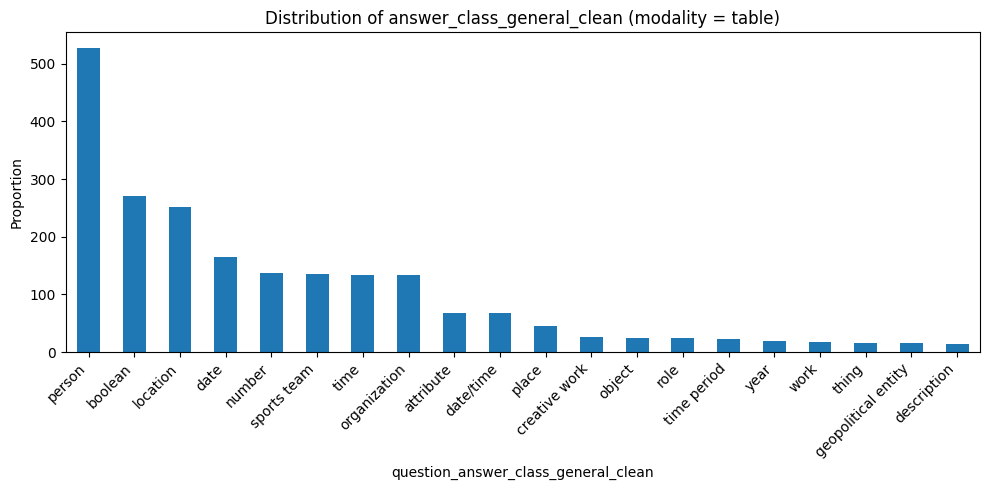

In [408]:
import matplotlib.pyplot as plt

# filter table modality
df_table = tree_dataset[tree_dataset["modality"].apply(lambda x: "text" in x)]

# distribution of answer classes
dist = df_table["question_answer_class_general_clean"].value_counts().sort_values(ascending=False)
print(dist[:20])

# plot
plt.figure(figsize=(10,5))
dist[:20].plot(kind="bar")
plt.ylabel("Proportion")
plt.title("Distribution of answer_class_general_clean (modality = table)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

question_answer_class_general_clean
person            664
organization      297
boolean           247
sports team       211
number            178
location          169
creative work     134
date              133
time              131
role              116
attribute          76
place              62
time period        54
film               51
work               47
object             35
date/time          31
event              29
role/character     24
chart              24
Name: count, dtype: int64


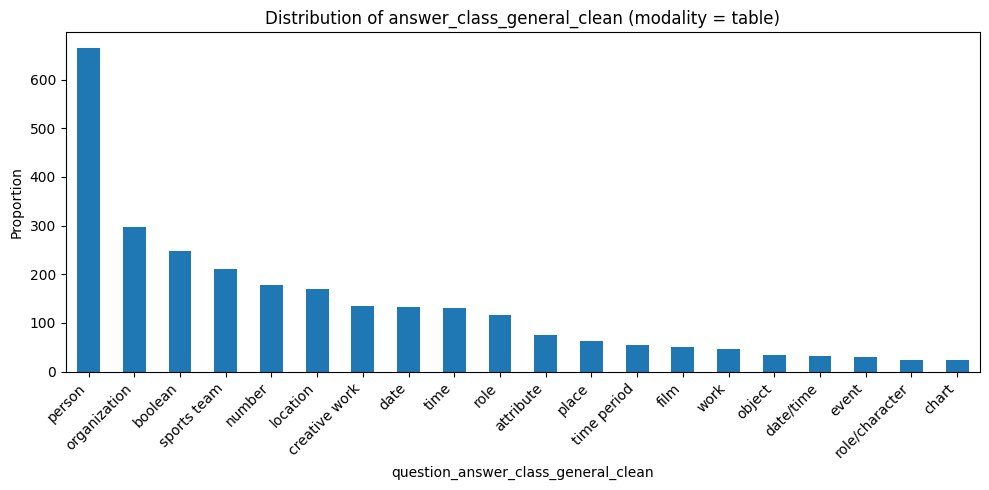

In [409]:
import matplotlib.pyplot as plt

# filter table modality
df_table = tree_dataset[tree_dataset["modality"].apply(lambda x: "table" in x)]

# distribution of answer classes
dist = df_table["question_answer_class_general_clean"].value_counts().sort_values(ascending=False)
print(dist[:20])

# plot
plt.figure(figsize=(10,5))
dist[:20].plot(kind="bar")
plt.ylabel("Proportion")
plt.title("Distribution of answer_class_general_clean (modality = table)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [384]:
columns = ["table"] # "table"] # "image_table", "image_text", "table_table", "table_text"]

In [385]:
def create_y(dataset, composed, columns):
    if not composed: 
        mlb = MultiLabelBinarizer()
        y = mlb.fit_transform(dataset["modality"])
    
        y = pd.DataFrame(y, columns=mlb.classes_)
        
        return y
    else: 
        print(dataset[dataset["modality"] == columns[0]])
        # y = pd.DataFrame(0, index=dataset.index, columns=columns)
        y = (dataset["modality"] == columns[0]).astype(int)
        
        return y
        
        """
        # Fill 1 where the modality matches the column name
        for i, row in dataset.iterrows():
            joined = row["modality"]
            if joined in y.columns:
                y.at[i, joined] = 1
            else: 
                y.at[i, joined] = 0
        
        return y
        """

In [386]:
def prepare_training_dataset(tree_dataset, min_count): 
    print(tree_dataset['modality'].value_counts())
    print(f"Sampling {min_count} rows per modality")
    
    df_equal = tree_dataset.groupby('modality').sample(n=min_count, random_state=42) # Step 3: Sample equally from each modality
    df_equal = df_equal.reset_index(drop=True)                                       # Step 4: Reset index if you want a clean DataFrame
    df_equal = df_equal.sample(frac=1, random_state=42).reset_index(drop=True)       # Shuffle the rows
    
    # X = df_equal[["question_length", "question_topic", "question_answer_class_general_reduced", "visual_elements"]]
    # X = df_equal[["question_answer_class_general_reduced", "year element"]] #, "year element"]]
    X = df_equal[["visual_elements", "year element"]]
    y = create_y(df_equal, True, columns)
    
    return df_equal, X, y

In [387]:
def prepare_tree(X, y): 
    # categorical_features = ["question_answer_class_general_reduced"] #, "question_topic"]
    boolean_features = ["year element", "visual_elements"] #, "year element"]
    
    preprocessor = ColumnTransformer(
        transformers=[
            # ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("bool", "passthrough", boolean_features)
        ]
    )
    
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=5, random_state=42))
    ])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return model, X_train, X_test, y_train, y_test

In [388]:
def evaluation_tree(tree_dataset, min_count):
    df_equal, X, y = prepare_training_dataset(tree_dataset, min_count)
    model, X_train, X_test, y_train, y_test = prepare_tree(X, y)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Test the model
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True) # target_names=y.columns)
    
    return report

In [389]:
df_equal, X, y = prepare_training_dataset(tree_dataset, 2500)

modality
table      3636
notable    2727
Name: count, dtype: int64
Sampling 2500 rows per modality
                                      original_question question_length  \
1     In the 1960 LPGA Tour, when the 1st prize was ...             111   
2     Which Other version of Bahurani (1963 film) wa...             144   
14    Where does the show where Kip Pardue plays FBI...              73   
15    was VII or VIII, the edition with earlier year...              68   
17    In the movie where Ted McGinley played Dan Ree...              85   
...                                                 ...             ...   
4993  Artoon developed which game title published by...             106   
4994  What was the meet's name during the Diamond Le...             122   
4995  Does Shannyn Sossamon's Gingy Wu TV series hav...              81   
4997  Who was the winner of the Margara Golf Open in...              52   
4998  What role did Adam Saunders play on numerous e...              67   



In [390]:
X

,visual_elements,year element
0,True,False
1,False,True
2,True,True
3,True,True
4,True,True
...,...,...
4995,True,False
4996,False,True
4997,False,True
4998,False,True


In [391]:
y

0       0
1       1
2       1
3       0
4       0
       ..
4995    1
4996    0
4997    1
4998    1
4999    0
Name: modality, Length: 5000, dtype: int64

In [392]:
samples = [100, 200, 300, 400, 500, 600, 700, 800, 1000, 2000, 2500]

In [393]:
reports = []
for sample in samples: 
    reports.append(evaluation_tree(tree_dataset, sample))

modality
table      3636
notable    2727
Name: count, dtype: int64
Sampling 100 rows per modality
                                     original_question question_length  \
3    Which away team had a replay for their tie num...             129   
4    During which year(s) was Karl Urban in Xena: W...              93   
5    Who was the short program by Yukari Nakano whe...              89   
7    For the 2007 ADAC Procar Series, who were the ...             118   
8    Where is the show that Folrencia Lozano play's...              79   
..                                                 ...             ...   
191  What was the Litex Lovech's D record when Lyub...              99   
193  in the Stadiums and locations of 2017–18 Bunde...             131   
195  Which is career statistics of Bryan Cabezas wh...              90   
198  Was Mary or Ana, the role with earlier year in...              83   
199  Which club did Andrei Girotto have less appear...              98   

    question_

In [394]:
reports

[{'0': {'precision': 0.6,
   'recall': 0.8181818181818182,
   'f1-score': 0.6923076923076923,
   'support': 22.0},
  '1': {'precision': 0.6,
   'recall': 0.3333333333333333,
   'f1-score': 0.42857142857142855,
   'support': 18.0},
  'accuracy': 0.6,
  'macro avg': {'precision': 0.6,
   'recall': 0.5757575757575758,
   'f1-score': 0.5604395604395604,
   'support': 40.0},
  'weighted avg': {'precision': 0.6,
   'recall': 0.6,
   'f1-score': 0.5736263736263736,
   'support': 40.0}},
 {'0': {'precision': 0.8947368421052632,
   'recall': 0.40476190476190477,
   'f1-score': 0.5573770491803278,
   'support': 42.0},
  '1': {'precision': 0.5901639344262295,
   'recall': 0.9473684210526315,
   'f1-score': 0.7272727272727273,
   'support': 38.0},
  'accuracy': 0.6625,
  'macro avg': {'precision': 0.7424503882657463,
   'recall': 0.6760651629072681,
   'f1-score': 0.6423248882265276,
   'support': 80.0},
  'weighted avg': {'precision': 0.7500647109577222,
   'recall': 0.6625,
   'f1-score': 0.6380

In [395]:
records = []

for size, report in zip(samples, reports):
    for label in report.keys():
        print("Label: ", label)
        # Skip aggregate rows if you want only modalities
        if label in ["micro avg", "macro avg", "weighted avg", "samples avg", "accuracy"]:
            continue
        
        records.append({
            "dataset_size": size,
            "label": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"]
        })

df = pd.DataFrame(records)

Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg
Label:  0
Label:  1
Label:  accuracy
Label:  macro avg
Label:  weighted avg


In [396]:
df.iloc[0].label

'0'

In [397]:
df["label"] = df["label"].apply(lambda x: "notable" if x == '0' else "table")

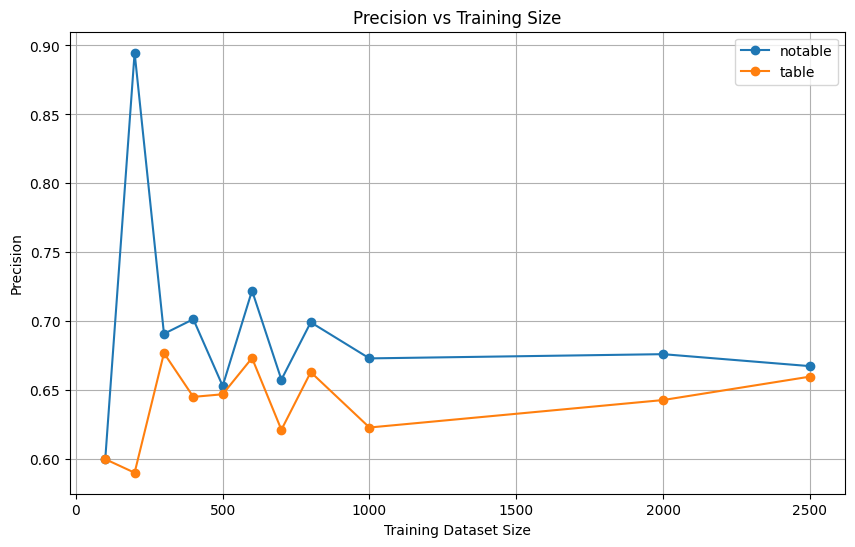

In [398]:
plt.figure(figsize=(10,6))

for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.plot(subset["dataset_size"],
             subset["precision"],
             marker="o",
             label=label)

plt.xlabel("Training Dataset Size")
plt.ylabel("Precision")
plt.title("Precision vs Training Size")
plt.legend()
plt.grid(True)
plt.show()

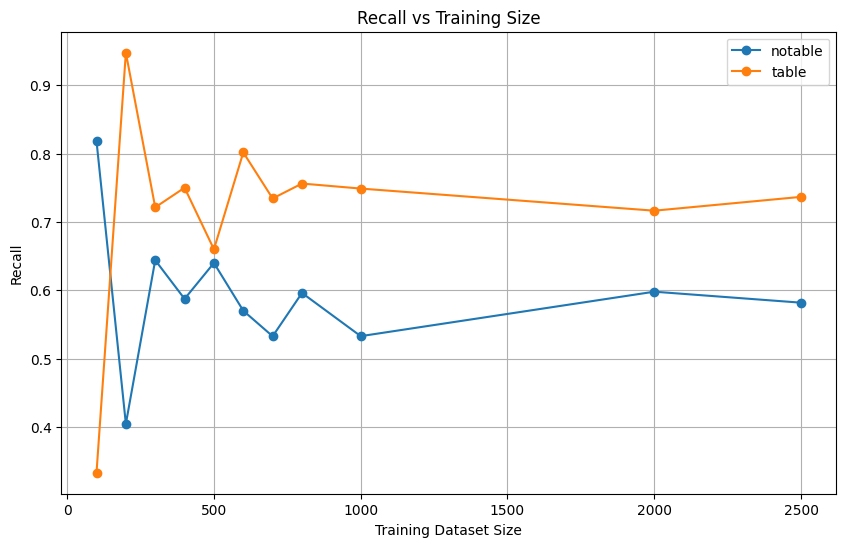

In [399]:
plt.figure(figsize=(10,6))

for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.plot(subset["dataset_size"],
             subset["recall"],
             marker="o",
             label=label)

plt.xlabel("Training Dataset Size")
plt.ylabel("Recall")
plt.title("Recall vs Training Size")
plt.legend()
plt.grid(True)
plt.show()

In [208]:
## Try XGBoost

In [210]:
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier

In [242]:
df_sample, X, y = prepare_training_dataset(tree_dataset, 909)

modality
table_table    909
table_text     909
image_table    909
image_text     909
table          909
text           909
image          909
Name: count, dtype: int64
Sampling 909 rows per modality


In [246]:
X["question_length"] = pd.to_numeric(X["question_length"])


X["visual_elements"] = X["visual_elements"].astype(int)

X = pd.get_dummies(
    X,
    columns=[
        "question_topic",
        "question_answer_class_general_reduced"
    ]
)

/var/folders/k3/0lt1r0j56bb6qcv0dylp_j0h0000gn/T/ipykernel_4537/676042247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["question_length"] = pd.to_numeric(X["question_length"])
/var/folders/k3/0lt1r0j56bb6qcv0dylp_j0h0000gn/T/ipykernel_4537/676042247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["visual_elements"] = X["visual_elements"].astype(int)


In [247]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [248]:
X_train

,question_length,visual_elements,question_topic_Buildings,question_topic_Economy,question_topic_Film,question_topic_Geography,question_topic_History,question_topic_Industry,question_topic_Literature,question_topic_Music,...,question_answer_class_general_reduced_object,question_answer_class_general_reduced_organization,question_answer_class_general_reduced_other,question_answer_class_general_reduced_person,question_answer_class_general_reduced_sports_event,question_answer_class_general_reduced_sports_stat,question_answer_class_general_reduced_sports_team,question_answer_class_general_reduced_text,question_answer_class_general_reduced_visual,question_answer_class_general_reduced_weather
4152,69,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6008,68,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3107,97,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
896,76,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4867,88,0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,56,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5191,43,1,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
5226,32,0,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
5390,93,0,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [249]:
# Define XGBoost model
model = OneVsRestClassifier(
    XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )
)

# Train
model.fit(X_train, y_train)

# Predict probabilities
y_proba = model.predict_proba(X_test)

# Threshold tuning (important in multi-label)
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

/Users/emanuelemezzi/PycharmProjects/LogicalEntropyGuidance/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/emanuelemezzi/PycharmProjects/LogicalEntropyGuidance/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/emanuelemezzi/PycharmProjects/LogicalEntropyGuidance/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:47:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/emanuelemezzi/PycharmProjects/LogicalEntropyGuidance/lib/python3.10/site-packages/xgboost/training.

In [250]:
report

{'0': {'precision': 0.6727272727272727,
  'recall': 0.7474747474747475,
  'f1-score': 0.7081339712918661,
  'support': 198.0},
 '1': {'precision': 0.42727272727272725,
  'recall': 0.5433526011560693,
  'f1-score': 0.47837150127226463,
  'support': 173.0},
 '2': {'precision': 0.6524064171122995,
  'recall': 0.648936170212766,
  'f1-score': 0.6506666666666666,
  'support': 188.0},
 '3': {'precision': 0.4448979591836735,
  'recall': 0.5891891891891892,
  'f1-score': 0.5069767441860465,
  'support': 185.0},
 '4': {'precision': 0.5336134453781513,
  'recall': 0.7134831460674157,
  'f1-score': 0.6105769230769231,
  'support': 178.0},
 '5': {'precision': 0.4609053497942387,
  'recall': 0.6787878787878788,
  'f1-score': 0.5490196078431373,
  'support': 165.0},
 '6': {'precision': 0.49760765550239233,
  'recall': 0.5591397849462365,
  'f1-score': 0.5265822784810127,
  'support': 186.0},
 'micro avg': {'precision': 0.5224071702944942,
  'recall': 0.6410054988216811,
  'f1-score': 0.5756613756613